<h1>Chapter 8 - Agentic RAG</h1>
<i>Building agents using LangGraph framework.</i>

<a href="https://learning.oreilly.com/library/view/rag-with-python/9798341600553/"><img src="https://img.shields.io/badge/O'Reilly-white.svg?logo=data:image/svg%2bxml;base64,PHN2ZyB3aWR0aD0iMzQiIGhlaWdodD0iMjciIHZpZXdCb3g9IjAgMCAzNCAyNyIgZmlsbD0ibm9uZSIgeG1sbnM9Imh0dHA6Ly93d3cudzMub3JnLzIwMDAvc3ZnIj4KPGNpcmNsZSBjeD0iMTMiIGN5PSIxNCIgcj0iMTEiIHN0cm9rZT0iI0Q0MDEwMSIgc3Ryb2tlLXdpZHRoPSI0Ii8+CjxjaXJjbGUgY3g9IjMwLjUiIGN5PSIzLjUiIHI9IjMuNSIgZmlsbD0iI0Q0MDEwMSIvPgo8L3N2Zz4K"></a>
<a href="https://github.com/polzerdo55862/RAG-with-Python-Cookbook"><img src="https://img.shields.io/badge/GitHub%20Repository-black?logo=github"></a>
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/polzerdo55862/RAG-with-Python-Cookbook/blob/main/ch08_agentic_rag/8.8_agentic_system_langgraph/building_agents_using_langgraph.ipynb)

---

This notebook is for Chapter 8 of the [RAG with Python Cookbook](https://learning.oreilly.com/library/view/rag-with-python/9798341600553/) book by [Dominik Polzer](https://www.linkedin.com/in/polzerdo/).

---

<a href="https://learning.oreilly.com/library/view/rag-with-python/9798341600553/">
  <img src="https://raw.githubusercontent.com/polzerdo55862/RAG-with-Python-Cookbook/main/rag_cookbook.png" width="350" />
</a>


### Building Agents using LangGraph

In [2]:
pip install langgraph geopy requests langchain_openai langchain-core pydantic

In [3]:
from typing import Annotated,Sequence, TypedDict

from langchain_core.messages import BaseMessage
# helper function to add messages to the state
from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    """The state of the agent."""
    messages: Annotated[Sequence[BaseMessage], add_messages]
    number_of_steps: int


In [4]:
from langchain_core.tools import tool
from geopy.geocoders import Nominatim
from pydantic import BaseModel, Field
import requests

geolocator = Nominatim(user_agent="weather-app")

class SearchInput(BaseModel):
    location: str = Field(
        description="The city and state, e.g., San Francisco"
    )
    date: str = Field(
        description="the forecasting date for when to get "
        "the weather format (yyyy-mm-dd)"
    )

@tool("get_weather_forecast", args_schema=SearchInput, return_direct=True)
def get_weather_forecast(location, date):
    """Retrieves the weather using Open-Meteo API for a given
    location (city) and a date (yyyy-mm-dd).
    Returns a dict mapping time -> temperature for each hour.
    """
    location = geolocator.geocode(location)
    if location:
        try:
            url = "https://api.open-meteo.com/v1/forecast"
            params = {
                "latitude": location.latitude,
                "longitude": location.longitude,
                "hourly": "temperature_2m",
                "start_date": date,
                "end_date": date,
            }
            response = requests.get(url, params=params)
            data = response.json()
            hourly = data.get("hourly", {})
            times = hourly.get("time", [])
            temps = hourly.get("temperature_2m", [])
            result = {}
            for t, temp in zip(times, temps):
                result[t] = temp
            return result
        except Exception as e:
            return {"error": str(e)}
    else:
        return {"error": "Location not found"}

class AudioInput(BaseModel):
    audio_path: str = Field(
        description="Path to the audio file to transcribe"
    )

@tool("transcribe_audio", args_schema=AudioInput, return_direct=True)
def transcribe_audio(audio_path):
    """Transcribe audio file into text using OpenAI Whisper."""
    try:
        with open(audio_path, "rb") as audio_file:
            transcript = openai.Audio.transcribe(
                model="whisper-1",
                file=audio_file
            )
            return transcript.text
    except Exception as e:
        return {"error": str(e)}

tools = [get_weather_forecast, transcribe_audio]


In [5]:
from datetime import datetime
from langchain_openai import ChatOpenAI

# Create LLM class
llm = ChatOpenAI(
    model="gpt-5.2",
    temperature=1.0,
    max_retries=2,
)

# Bind tools to the model
model = llm.bind_tools([get_weather_forecast])

# Test the model with tools
query = f"What is the weather in Berlin on {datetime.today()}?"
res = model.invoke(query)

print(res)


In [6]:
from langchain_core.messages import ToolMessage
from langchain_core.runnables import RunnableConfig

tools_by_name = {}
for _t in tools:
    tools_by_name[_t.name] = _t

# Define our tool node
def call_tool(state: AgentState):
    outputs = []
    # Iterate over the tool calls in the last message
    for tool_call in state["messages"][-1].tool_calls:
        # Get the tool by name and arguments in smaller steps
        # to keep lines short
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        tool_obj = tools_by_name[tool_name]
        tool_result = tool_obj.invoke(tool_args)
        outputs.append(
            ToolMessage(
                content=tool_result,
                name=tool_name,
                tool_call_id=tool_call["id"],
            )
        )
    return {"messages": outputs}

def call_model(
    state: AgentState,
    config: RunnableConfig,
):
    # Invoke the model with the system prompt and the messages
    response = model.invoke(state["messages"], config)
    # Return a list, because this will get added to the
    # existing messages state using the add_messages reducer
    return {"messages": [response]}


# Define the conditional edge that determines whether to continue or not
def should_continue(state: AgentState):
    messages = state["messages"]
    # If the last message is not a tool call, then finish
    if not messages[-1].tool_calls:
        return "end"
    # default to continue
    return "continue"


In [8]:
from langgraph.graph import StateGraph, END

# Define a new graph with our state
workflow = StateGraph(AgentState)

# 1. Add our nodes
workflow.add_node("llm", call_model)
workflow.add_node("tools",  call_tool)
# 2. Set the entrypoint as `agent`, this is the first node called
workflow.set_entry_point("llm")
# 3. Add a conditional edge after the `llm` node is called.
workflow.add_conditional_edges(
    # Edge is used after the `llm` node is called.
    "llm",
    # The function that will determine which node is called next.
    should_continue,
    # Mapping for where to go next, keys are strings from the
    # function return, and the values are other nodes.
    # END is a special node marking that the graph is finish.
    {
        # If `tools`, then call the tool node.
        "continue": "tools",
        # Otherwise finish.
        "end": END,
    },
)
# 4. Add a normal edge after `tools` is called, `llm` node is called next.
workflow.add_edge("tools", "llm")

# Now you can compile and visualize the graph
graph = workflow.compile()


APIConnectionError: Connection error.

In [9]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [10]:
from datetime import datetime

# Create our initial message dictionary
inputs = {
    "messages": [
        ("user", f"What is the weather in Berlin on {datetime.today()}?")
    ]
}

# Call our graph with streaming to see the steps
for state in graph.stream(inputs, stream_mode="values"):
    last_message = state["messages"][-1]
    last_message.pretty_print()


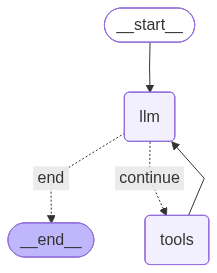

In [ ]:
state["messages"].append(("user", "Would it be in Munich warmer?"))

for state in graph.stream(state, stream_mode="values"):
    last_message = state["messages"][-1]
    last_message.pretty_print()


In [ ]:
# tag::run_graph[]
from datetime import datetime

# Create our initial message dictionary
inputs = {"messages": [("user", f"What is the weather in Berlin on {datetime.today()}?")]}

# Call our graph with streaming to see the steps
for state in graph.stream(inputs, stream_mode="values"):
    last_message = state["messages"][-1]
    last_message.pretty_print()
# end::run_graph[]

================================ Human Message =================================

What is the weather in Berlin on 2025-10-27 20:14:41.943957?
================================== Ai Message ==================================
Tool Calls:
  get_weather_forecast (call_ioOweHeh6egt1sDcafLplsW4)
 Call ID: call_ioOweHeh6egt1sDcafLplsW4
  Args:
    location: Berlin
    date: 2025-10-27
================================= Tool Message =================================
Name: get_weather_forecast

{'2025-10-27T00:00': 8.0, '2025-10-27T01:00': 7.7, '2025-10-27T02:00': 7.3, '2025-10-27T03:00': 6.8, '2025-10-27T04:00': 6.5, '2025-10-27T05:00': 6.4, '2025-10-27T06:00': 6.5, '2025-10-27T07:00': 6.6, '2025-10-27T08:00': 6.9, '2025-10-27T09:00': 7.3, '2025-10-27T10:00': 8.0, '2025-10-27T11:00': 8.9, '2025-10-27T12:00': 9.4, '2025-10-27T13:00': 9.9, '2025-10-27T14:00': 9.5, '2025-10-27T15:00': 9.4, '2025-10-27T16:00': 9.1, '2025-10-27T17:00': 8.9, '2025-10-27T18:00': 8.7, '2025-10-27T19:00': 8.5, '2025-10-

In [ ]:
# tag::continue_conversation[]
state["messages"].append(("user", "Would it be in Munich warmer?"))

for state in graph.stream(state, stream_mode="values"):
    last_message = state["messages"][-1]
    last_message.pretty_print()
# end::continue_conversation[]

================================ Human Message =================================

Would it be in Munich warmer?
================================== Ai Message ==================================
Tool Calls:
  get_weather_forecast (call_qWMBRRURg7dKAxDMj0MRXwKf)
 Call ID: call_qWMBRRURg7dKAxDMj0MRXwKf
  Args:
    location: Munich
    date: 2025-10-27
================================= Tool Message =================================
Name: get_weather_forecast

{'2025-10-27T00:00': 5.4, '2025-10-27T01:00': 5.5, '2025-10-27T02:00': 5.4, '2025-10-27T03:00': 5.8, '2025-10-27T04:00': 5.8, '2025-10-27T05:00': 5.7, '2025-10-27T06:00': 5.2, '2025-10-27T07:00': 5.7, '2025-10-27T08:00': 6.1, '2025-10-27T09:00': 6.1, '2025-10-27T10:00': 5.9, '2025-10-27T11:00': 6.3, '2025-10-27T12:00': 6.8, '2025-10-27T13:00': 7.3, '2025-10-27T14:00': 7.6, '2025-10-27T15:00': 7.4, '2025-10-27T16:00': 7.1, '2025-10-27T17:00': 7.0, '2025-10-27T18:00': 7.4, '2025-10-27T19:00': 7.4, '2025-10-27T20:00': 7.3, '2025-10-27T21: